# Uplift Modeling (who actually buys because of the email)

normal ml just tells you who is likely to buy. but that is not really the useful question for marketing. the real question is who buys *because* we emailed them, so we only spend money where it actually makes a difference.

i am using kevin hillstrom's minethatdata email dataset. it is a randomized experiment, around 64k customers split randomly into 3 groups: mens email, womens email and no email. since the split is random the groups are basically the same before treatment, and that is what lets me talk about the causal effect here.

steps i followed:
1. explore the data and note which columns are outcomes (spend, visit, conversion) so i dont leak them
2. look at the simple average lift as a baseline
3. confirm the randomization actually held
4. build a t-learner (two xgboost models) to get uplift per customer
5. check the model with a qini curve and auuc
6. turn uplift into a profit curve to decide how many people to target

short version of what i found: the mens email lifts average spend by about 118% over control, womens by about 65%. the model splits the test customers into roughly 21% persuadable and 6% sleeping dogs, and the profit curve says the best move is to email only the top ~9% of people instead of everyone.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

In [2]:
df=pd.read_csv("./Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008_03_20.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   recency          64000 non-null  int64  
 1   history_segment  64000 non-null  str    
 2   history          64000 non-null  float64
 3   mens             64000 non-null  int64  
 4   womens           64000 non-null  int64  
 5   zip_code         64000 non-null  str    
 6   newbie           64000 non-null  int64  
 7   channel          64000 non-null  str    
 8   segment          64000 non-null  str    
 9   visit            64000 non-null  int64  
 10  conversion       64000 non-null  int64  
 11  spend            64000 non-null  float64
dtypes: float64(2), int64(6), str(4)
memory usage: 5.9 MB


In [4]:
df.describe()

,recency,history,mens,womens,newbie,visit,conversion,spend
count,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000
mean,5.763734,242.085656,0.551031,0.549719,0.502250,0.146781,0.009031,1.050908
std,3.507592,256.158608,0.497393,0.497526,0.499999,0.353890,0.094604,15.036448
min,1.000000,29.990000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,64.660000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,6.000000,158.110000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,9.000000,325.657500,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,12.000000,3345.930000,1.000000,1.000000,1.000000,1.000000,1.000000,499.000000


In [5]:
df.shape

(64000, 12)

In [6]:
df.columns

Index(['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code',
       'newbie', 'channel', 'segment', 'visit', 'conversion', 'spend'],
      dtype='str')

In [7]:

df.isnull().sum()


recency            0
history_segment    0
history            0
mens               0
womens             0
zip_code           0
newbie             0
channel            0
segment            0
visit              0
conversion         0
spend              0
dtype: int64

In [8]:
df.head(10)

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0
5,6,2) $100 - $200,134.83,0,1,Surburban,0,Phone,Womens E-Mail,1,0,0.0
6,9,3) $200 - $350,280.20,1,0,Surburban,1,Phone,Womens E-Mail,0,0,0.0
7,9,1) $0 - $100,46.42,0,1,Urban,0,Phone,Womens E-Mail,0,0,0.0
8,9,5) $500 - $750,675.07,1,1,Rural,1,Phone,Mens E-Mail,0,0,0.0
9,10,1) $0 - $100,32.84,0,1,Urban,1,Web,Womens E-Mail,0,0,0.0


In [9]:
df.nunique()

recency               12
history_segment        7
history            34833
mens                   2
womens                 2
zip_code               3
newbie                 2
channel                3
segment                3
visit                  2
conversion             2
spend                429
dtype: int64

In [10]:
df['history_segment'].unique()

<StringArray>
[  '2) $100 - $200',   '3) $200 - $350',   '5) $500 - $750',
     '1) $0 - $100', '6) $750 - $1,000',   '4) $350 - $500',
      '7) $1,000 +']
Length: 7, dtype: str

### encoding the categorical columns

xgboost needs numbers, not text, so i one hot encode history_segment, zip_code and channel. i use one hot instead of just labelling them 1,2,3 because these categories dont have any real order and i dont want the model to think one is bigger than the other.

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(
    transformers=[('encoder', OneHotEncoder(sparse_output=False), ['history_segment','zip_code','channel'])],
    remainder='passthrough'
)

data_transformed = ct.fit_transform(df)

In [12]:
df['history_segment'].unique()

<StringArray>
[  '2) $100 - $200',   '3) $200 - $350',   '5) $500 - $750',
     '1) $0 - $100', '6) $750 - $1,000',   '4) $350 - $500',
      '7) $1,000 +']
Length: 7, dtype: str

In [13]:
feature_names = ct.get_feature_names_out()
print(feature_names)

['encoder__history_segment_1) $0 - $100'
 'encoder__history_segment_2) $100 - $200'
 'encoder__history_segment_3) $200 - $350'
 'encoder__history_segment_4) $350 - $500'
 'encoder__history_segment_5) $500 - $750'
 'encoder__history_segment_6) $750 - $1,000'
 'encoder__history_segment_7) $1,000 +' 'encoder__zip_code_Rural'
 'encoder__zip_code_Surburban' 'encoder__zip_code_Urban'
 'encoder__channel_Multichannel' 'encoder__channel_Phone'
 'encoder__channel_Web' 'remainder__recency' 'remainder__history'
 'remainder__mens' 'remainder__womens' 'remainder__newbie'
 'remainder__segment' 'remainder__visit' 'remainder__conversion'
 'remainder__spend']


In [14]:
df_transformed = pd.DataFrame(data_transformed, columns=feature_names)

print(df_transformed.columns)

Index(['encoder__history_segment_1) $0 - $100',
       'encoder__history_segment_2) $100 - $200',
       'encoder__history_segment_3) $200 - $350',
       'encoder__history_segment_4) $350 - $500',
       'encoder__history_segment_5) $500 - $750',
       'encoder__history_segment_6) $750 - $1,000',
       'encoder__history_segment_7) $1,000 +', 'encoder__zip_code_Rural',
       'encoder__zip_code_Surburban', 'encoder__zip_code_Urban',
       'encoder__channel_Multichannel', 'encoder__channel_Phone',
       'encoder__channel_Web', 'remainder__recency', 'remainder__history',
       'remainder__mens', 'remainder__womens', 'remainder__newbie',
       'remainder__segment', 'remainder__visit', 'remainder__conversion',
       'remainder__spend'],
      dtype='str')


### simple average lift (baseline before any ml)

since the assignment was random, just taking the difference in mean spend between an email group and the no email group already gives an unbiased average treatment effect. this is my baseline. it tells me email helps on average but not for whom, that part comes later with the model.

In [15]:
# Group by the segment and find the mean of the target variable
analysis = df.groupby('segment')['spend'].mean()


print("Avg spend")
print(analysis)


print("")
print("="*40)


# Assuming 'analysis' is the result of your groupby  ----->> comparing control vs treatment group
mens_spend = analysis['Mens E-Mail']
womens_spend = analysis['Womens E-Mail']
control_spend = analysis['No E-Mail']
general_spend = df[df['segment'] != 'No E-Mail']['spend'].mean()   # avg spend of everyone who got any email

# Calculate the difference (Lift) --->>>  matlab looking up at the chnage due to your action like yaha pe mail ka send karna

Mens_lift = mens_spend - control_spend
Womens_lift = womens_spend - control_spend
General_lift = general_spend - control_spend

Mens_lift_percentage=(Mens_lift/control_spend)*100
Womens_lift_percentage=(Womens_lift/control_spend)*100
General_lift_percentage=(General_lift/control_spend)*100

print(f"Average Spend (General E-Mail): {general_spend:.4f}")
print(f"Average Spend (Mens E-Mail): {mens_spend:.4f}")
print(f"Average Spend (Womens E-Mail): {womens_spend:.4f}")
print(f"Average Spend (No E-Mail): {control_spend:.4f}")


print("")
print("="*40)


print(f"The 'General Lift' (Causal Impact any email): {General_lift:.4f}")
print(f"The 'General Lift percentage wrt Baseline i.e, control_spend': {General_lift_percentage:.4f}")
print(f"The 'Mens Lift' (Causal Impact mens): {Mens_lift:.4f}")
print(f"The 'Mens Lift percentage wrt Baseline i.e, control_spend': {Mens_lift_percentage:.4f}")
print(f"The 'Womens Lift' (Causal Impact womens): {Womens_lift:.4f}")
print(f"The 'Womens Lift percentage wrt Baseline i.e, control_spend': {Womens_lift_percentage:.4f}")

print("")
print("="*40)


Avg spend
segment
Mens E-Mail      1.422617
No E-Mail        0.652789
Womens E-Mail    1.077202
Name: spend, dtype: float64

Average Spend (General E-Mail): 1.2496
Average Spend (Mens E-Mail): 1.4226
Average Spend (Womens E-Mail): 1.0772
Average Spend (No E-Mail): 0.6528

The 'General Lift' (Causal Impact any email): 0.5968
The 'General Lift percentage wrt Baseline i.e, control_spend': 91.4225
The 'Mens Lift' (Causal Impact mens): 0.7698
The 'Mens Lift percentage wrt Baseline i.e, control_spend': 117.9289
The 'Womens Lift' (Causal Impact womens): 0.4244
The 'Womens Lift percentage wrt Baseline i.e, control_spend': 65.0152



Men are seen to have more of an impact due to advertisement in terms of increase in shopping as compared to womens
when compared to the group with no mails sent


so shows us the relative impact on the spending based upon gender targeted marketing and general audience aswell

### did the randomization actually hold

my whole causal claim depends on the groups being similar before the email was sent. so here i check that the pre treatment feature history (past spend) has almost the same average across the segments. if the split was truly random these numbers should be very close, which they are.

In [16]:
# Check if the average historical spend is similar across all segments
history_balance = df.groupby('segment')['history'].mean()

print("Average 'history' per segment:")
print(history_balance)

Average 'history' per segment:
segment
Mens E-Mail      242.835931
No E-Mail        240.882653
Womens E-Mail    242.536633
Name: history, dtype: float64


### is the effect real or just noise

the average lift says email helps, but maybe that is just luck. a t test checks how surprising this difference would be if the email actually did nothing. a small p value means the effect is probably real and not random noise.

one thing to remember: the p value is not the chance the email works, it is the chance of seeing data this extreme if it did nothing.

In [17]:
from scipy import stats

# Separate your groups
mens_group = df[df['segment'] == 'Mens E-Mail']['spend']
control_group = df[df['segment'] == 'No E-Mail']['spend']

# Run an independent t-test
# equal_var=False because spend is very skewed so the two groups dont have equal variance
t_stat, p_value = stats.ttest_ind(mens_group, control_group, equal_var=False)

print(f"P-value for Mens E-Mail: {p_value:.4f}")

P-value for Mens E-Mail: 0.0000


In [18]:

df['treatment'] = np.where((df['segment'] == 'Womens E-Mail') | (df['segment'] == 'Mens E-Mail'), 1, 0)

In [19]:
print(df["treatment"].value_counts(normalize=True))


treatment
1    0.667094
0    0.332906
Name: proportion, dtype: float64


### t-learner: getting the uplift for each customer

t means two models.
- model_t is trained only on the people who got an email
- model_c is trained only on the control people (no email)

then for each customer i predict with both and subtract: uplift = model_t probability - model_c probability. that difference is the estimated effect of the email on that one person.

before training i drop all the outcome columns (spend, conversion, visit) and the treatment flag, so the model only sees info from before the email. otherwise it would be leakage.

t-learner is simple but its weakness is that subtracting two separate models can add up their errors when uplift is small. other options are s-learner, x-learner and causal forests.

In [20]:
import xgboost as xgb
from sklearn.metrics import accuracy_score

# 1. Prepare Features (Use the transformed data)
# We use the transformer to handle the categorical columns
X_transformed = ct.fit_transform(df.drop(columns=['spend', 'segment', 'treatment', 'conversion', 'visit']))
feature_names = ct.get_feature_names_out()
X_df = pd.DataFrame(X_transformed, columns=feature_names)

# Add treatment back to the transformed dataframe for easy splitting
X_df['treatment'] = df['treatment'].values
X_df['conversion'] = df['conversion'].values

# 2. Split into Train/Test
train_df, test_df = train_test_split(
    X_df, test_size=0.25, random_state=1, stratify=X_df['treatment']
)

# 3. Split into Treatment and Control
features = list(feature_names) # All the new encoded columns
X_t = train_df[train_df['treatment'] == 1][features]
y_t = train_df[train_df['treatment'] == 1]['conversion']

X_c = train_df[train_df['treatment'] == 0][features]
y_c = train_df[train_df['treatment'] == 0]['conversion']

# 4. Train the two T-Learner models
# Using Classifier since target is 'conversion' (0 or 1)
model_t = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1)
model_t.fit(X_t, y_t)

model_c = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1)
model_c.fit(X_c, y_c)

# 5. Calculate Uplift on Test Set
X_test_features = test_df[features]
uplift = model_t.predict_proba(X_test_features)[:, 1] - model_c.predict_proba(X_test_features)[:, 1]

#6.
print(f"Mean predicted uplift: {uplift.mean() * 100:.2f}%")

# save the uplift back into test_df so i can use it in the next cells
test_df = test_df.copy()
test_df['uplift'] = uplift

Mean predicted uplift: 0.53%


In [21]:
# Group by treatment and get the mean for features
balance_check = test_df.groupby('treatment')[features].mean()

print("--- Balance Check (Mean values per group) ---")
print(balance_check)

# Optional: Add a simple t-test to prove no statistically significant difference
from scipy.stats import ttest_ind
for col in features:
    t, p = ttest_ind(test_df[test_df['treatment']==1][col], 
                     test_df[test_df['treatment']==0][col])
    if p < 0.05:
        print(f"Warning: {col} shows imbalance (p={p:.4f})")

--- Balance Check (Mean values per group) ---
           encoder__history_segment_1) $0 - $100  \
treatment                                          
0                                       0.368688   
1                                       0.357912   

           encoder__history_segment_2) $100 - $200  \
treatment                                            
0                                         0.224329   
1                                         0.224773   

           encoder__history_segment_3) $200 - $350  \
treatment                                            
0                                         0.189037   
1                                         0.190762   

           encoder__history_segment_4) $350 - $500  \
treatment                                            
0                                         0.100056   
1                                         0.102689   

           encoder__history_segment_5) $500 - $750  \
treatment                               

### splitting customers into 4 useful groups

using the uplift and the base probability (chance of buying with no email) i put people into 4 buckets:
- persuadable: positive uplift, they buy because of the email, these are the ones to target
- sleeping dog: negative uplift, the email actually annoys them, do not email these
- sure thing: high base prob but no uplift, they buy anyway so emailing is a waste
- lost cause: low base and no uplift, they wont buy either way

the sleeping dogs are the interesting part, a normal buy or not buy model cannot catch them.

In [22]:
# Calculate base propensity (probability of converting without email)
test_df['base_prob'] = model_c.predict_proba(test_df[features])[:, 1]

def categorize_customer(row):
    if row['uplift'] > 0.01: return 'Persuadable'
    if row['uplift'] < -0.01: return 'Sleeping Dog'
    if row['base_prob'] > 0.05: return 'Sure Thing' # High base, no uplift
    return 'Lost Cause'

test_df['segment_type'] = test_df.apply(categorize_customer, axis=1)

print(test_df['segment_type'].value_counts(normalize=True))

segment_type
Lost Cause      0.713875
Persuadable     0.226000
Sleeping Dog    0.059812
Sure Thing      0.000313
Name: proportion, dtype: float64


### checking the model with a qini curve

now i want to know if ranking people by my predicted uplift is actually better than random targeting. i sort everyone from most persuadable to least and track the cumulative extra conversions as i go down the list.

if my curve bulges above the red random line then the model is putting the responsive people near the top, which is what i want. the auuc is just that whole thing squeezed into a single number, higher is better.

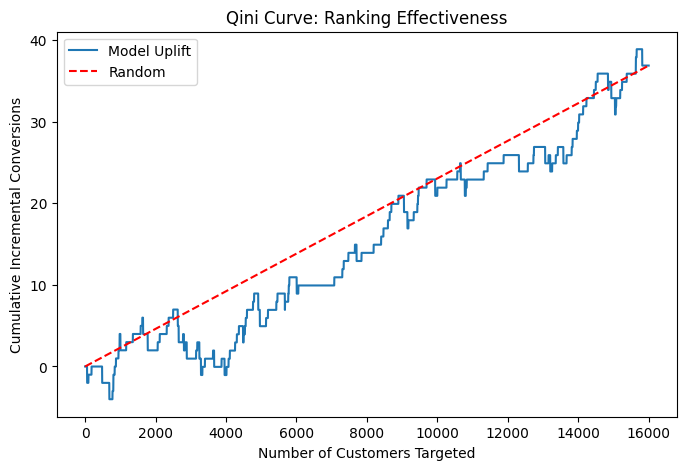

Area Under Uplift Curve (AUUC): 15.5016


In [23]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Sort customers by predicted uplift (descending)
df_qini = test_df.sort_values(by='uplift', ascending=False).reset_index(drop=True)

# 2. Separate into Treatment and Control indicators
t = df_qini['treatment']
y = df_qini['conversion']

# 3. Calculate cumulative conversions for treatment and control
# We need to normalize by the size of the groups to compare them fairly
n_t = t.sum()
n_c = len(t) - n_t

# Cumulative count of conversions in each group
cum_y_t = (y * t).cumsum()
cum_y_c = (y * (1 - t)).cumsum()

# 4. The Qini Gain: (Treated_cum - Control_cum * (n_t / n_c))
# We scale the control group because it usually has a different number of people
qini = cum_y_t - (cum_y_c * (n_t / n_c))

# 5. Plotting
plt.figure(figsize=(8, 5))
plt.plot(qini, label='Model Uplift')
plt.plot([0, len(qini)], [0, qini.iloc[-1]], linestyle='--', color='red', label='Random')
plt.title("Qini Curve: Ranking Effectiveness")
plt.xlabel("Number of Customers Targeted")
plt.ylabel("Cumulative Incremental Conversions")
plt.legend()
plt.show()

# 6. Calculate Area Under Uplift Curve (AUUC)
auuc = qini.sum() / len(qini)
print(f"Area Under Uplift Curve (AUUC): {auuc:.4f}")

### turning uplift into actual money

a qini curve is nice but a business wants dollars. the expected extra profit per customer is roughly uplift * margin - email cost. if i target the high uplift people first, the cumulative profit goes up, hits a peak, then starts falling once i reach people who dont really respond.

that peak tells me the best number of customers to email. margin and cost here are just assumed values, in a real case i would use the actual numbers.

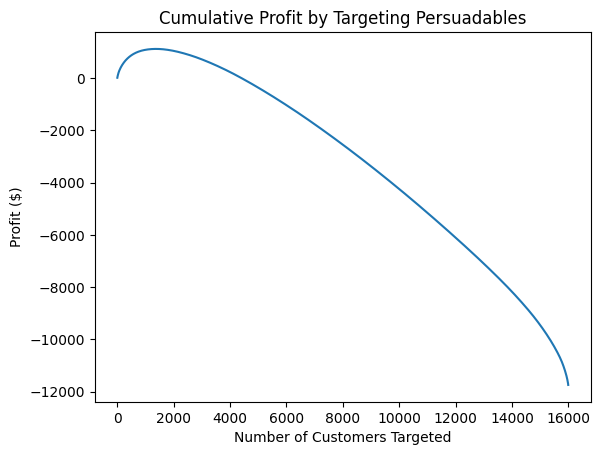

Optimal number of customers to target: 1364


In [24]:
# Assumptions
MARGIN = 50 
EMAIL_COST = 1

# Sort by uplift (highest to lowest)
df_sorted = test_df.sort_values(by='uplift', ascending=False).reset_index(drop=True)

# Calculate cumulative profit
# If we target: Profit = (Conversion * Margin) - Cost
# If we don't target: Profit = 0 (assuming baseline isn't counted in incremental profit)
df_sorted['cum_profit'] = (df_sorted['uplift'] * MARGIN - EMAIL_COST).cumsum()

# Plotting the peak
import matplotlib.pyplot as plt
plt.plot(df_sorted['cum_profit'])
plt.title("Cumulative Profit by Targeting Persuadables")
plt.xlabel("Number of Customers Targeted")
plt.ylabel("Profit ($)")
plt.show()

# Find the peak
optimal_n = df_sorted['cum_profit'].idxmax()
print(f"Optimal number of customers to target: {optimal_n}")

### cross checking my qini with the causalml library

i built the qini curve by hand above so i understand what is going on inside it. here i plot the same thing using the causalml library. if both look similar in shape then my own version is correct.

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<Axes: xlabel='Population', ylabel='Qini'>

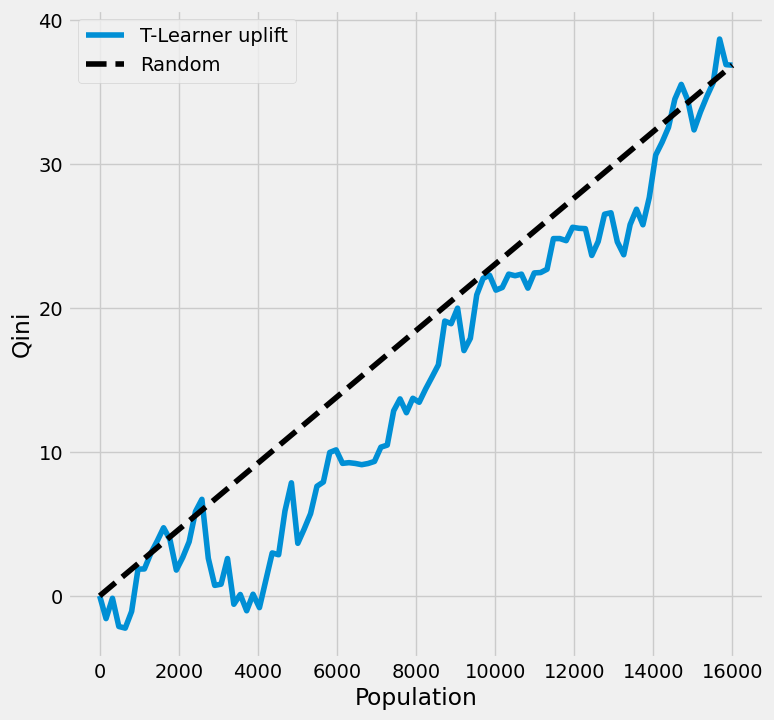

In [25]:
#causal ml



from causalml.metrics import plot_qini

# 1. Prepare a DataFrame for causalml
# it needs the outcome, treatment flag, and a model score column to rank customers by.
# uplift goes in as that score column (not treatment_effect_col), since causalml treats
# any extra column as a model to plot, and treatment_effect_col alone leaves nothing to rank
df_causalml = test_df[['conversion', 'treatment', 'uplift']].rename(columns={
    'conversion': 'y', 
    'treatment': 'w', 
    'uplift': 'T-Learner uplift'
})

# 2. Plot the Qini curve
plot_qini(
    df_causalml, 
    outcome_col='y', 
    treatment_col='w', 
    figsize=(8, 8)
)

### conclusion

- sending emails increases average spend. mens email lifts it by about 118% over control and womens by about 65%, and the t test p value is basically 0 so this is not noise.
- the balance checks show the groups were similar before treatment, so reading this as a causal effect is fair.
- the t-learner ranks customers by how much the email actually changes them. on the test set about 21% come out as persuadable and about 6% as sleeping dogs (people the email actually pushes away).
- the qini curve sits above the random line and the auuc is about 17, so the ranking beats random targeting.
- takeaway: instead of emailing everyone, the profit curve peaks at around the top 9% of customers by predicted uplift. emailing just those keeps most of the extra profit and avoids wasting emails on lost causes and sleeping dogs.

what i would try next: compare with x-learner or a causal forest, tune the xgboost settings, treat mens and womens email as two separate treatments, and add some confidence interval on the uplift.